# Spine Measurement Readiness - Best Model

This notebook presents the recommended HRNet-W18 epoch-49 `best_usable_recall.pt` evaluation as an editable, one-page dashboard. It uses **spine-chain output only** and emphasizes vertebral detection, corner localization, counting, and Cobb-angle measurement.

**Research boundary:** No fracture labels or validated fracture classifier are used. These are measurement-readiness metrics that require clinical review; they are not fracture or disease-detection performance.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src').is_dir() and (candidate / 'outputs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the Spine Opportunistic Screening project root.')


PROJECT_ROOT = find_project_root(Path.cwd())
EVALUATION_ROOT = PROJECT_ROOT / 'outputs/evaluations/30 Aug 2026 80 epochs'
CHECKPOINT_ROOT = EVALUATION_ROOT / 'best_usable_recall'
METRICS_CSV = CHECKPOINT_ROOT / 'metrics.csv'
METRICS_JSON = CHECKPOINT_ROOT / 'metrics.json'
MANIFEST_JSON = EVALUATION_ROOT / 'evaluation_manifest.json'
OUTPUT_PNG = PROJECT_ROOT / 'outputs/visualization/vertebral-performance-bar-dashboard.png'

required_paths = (METRICS_CSV, METRICS_JSON, MANIFEST_JSON)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f'Missing required evaluation artifacts: {missing_paths}')

metrics = pd.read_csv(METRICS_CSV)
with METRICS_JSON.open(encoding='utf-8') as handle:
    metrics_payload = json.load(handle)
with MANIFEST_JSON.open(encoding='utf-8') as handle:
    manifest = json.load(handle)

overall = metrics.loc[
    metrics['model'].eq('spine_chain')
    & metrics['scope'].eq('overall_micro')
    & metrics['source_dataset'].isna()
].copy()
if len(overall) != 1:
    raise ValueError(f'Expected one spine-chain overall row; found {len(overall)}.')
overall = overall.iloc[0]

checkpoint = Path(metrics_payload['metadata']['checkpoint']).name
recommended = manifest.get('recommended_checkpoint')
if recommended and checkpoint != recommended:
    raise ValueError(f'Expected recommended checkpoint {recommended}; received {checkpoint}.')
epoch = manifest.get('checkpoints', {}).get(checkpoint, {}).get('epoch')
backbone = metrics_payload.get('metadata', {}).get('settings', {}).get('backbone')
backbone_label = {'hrnet_w18': 'HRNet-W18'}.get(backbone, str(backbone))
source_count = metrics.loc[
    metrics['model'].eq('spine_chain') & metrics['scope'].eq('source'),
    'source_dataset',
].nunique()

values = {
    'detection_f1': 100 * float(overall['center_f1_0.20d']),
    'detection_precision': 100 * float(overall['center_precision_0.20d']),
    'detection_recall': 100 * float(overall['center_recall_0.20d']),
    'corner_accuracy': 100 * float(overall['pck_0.10']),
    'corner_end_to_end': 100 * float(overall['end_to_end_pck_0.10']),
    'corner_error_mean': 100 * float(overall['corner_nme_mean']),
    'corner_error_median': 100 * float(overall['corner_nme_median']),
    'corner_error_p95': 100 * float(overall['corner_nme_p95']),
    'count_mae': float(overall['count_mae']),
    'count_within_one': 100 * float(overall['count_within_one_rate']),
    'cobb_mae': float(overall['cobb_mae_deg']),
    'cobb_within_five': 100 * float(overall['cobb_within_5deg_rate']),
    'cobb_within_ten': 100 * float(overall['cobb_within_10deg_rate']),
}

print(
    f'Loaded {int(overall["images"]):,} radiographs and '
    f'{int(overall["gt_vertebrae"]):,} reference vertebrae from '
    f'{source_count} sources | {backbone_label} | epoch {epoch} | {checkpoint}'
)

Loaded 223 radiographs and 3,060 reference vertebrae from 5 sources | HRNet-W18 | epoch 49 | best_usable_recall.pt


## One-page metric dashboard

The five summary metrics remain visible as cards. The bar chart focuses on **Vertebral Detection F1**, **Corner Localization Accuracy**, and **Mean Relative Corner Error**. Each bar uses its native unit and an explicitly labeled scale.

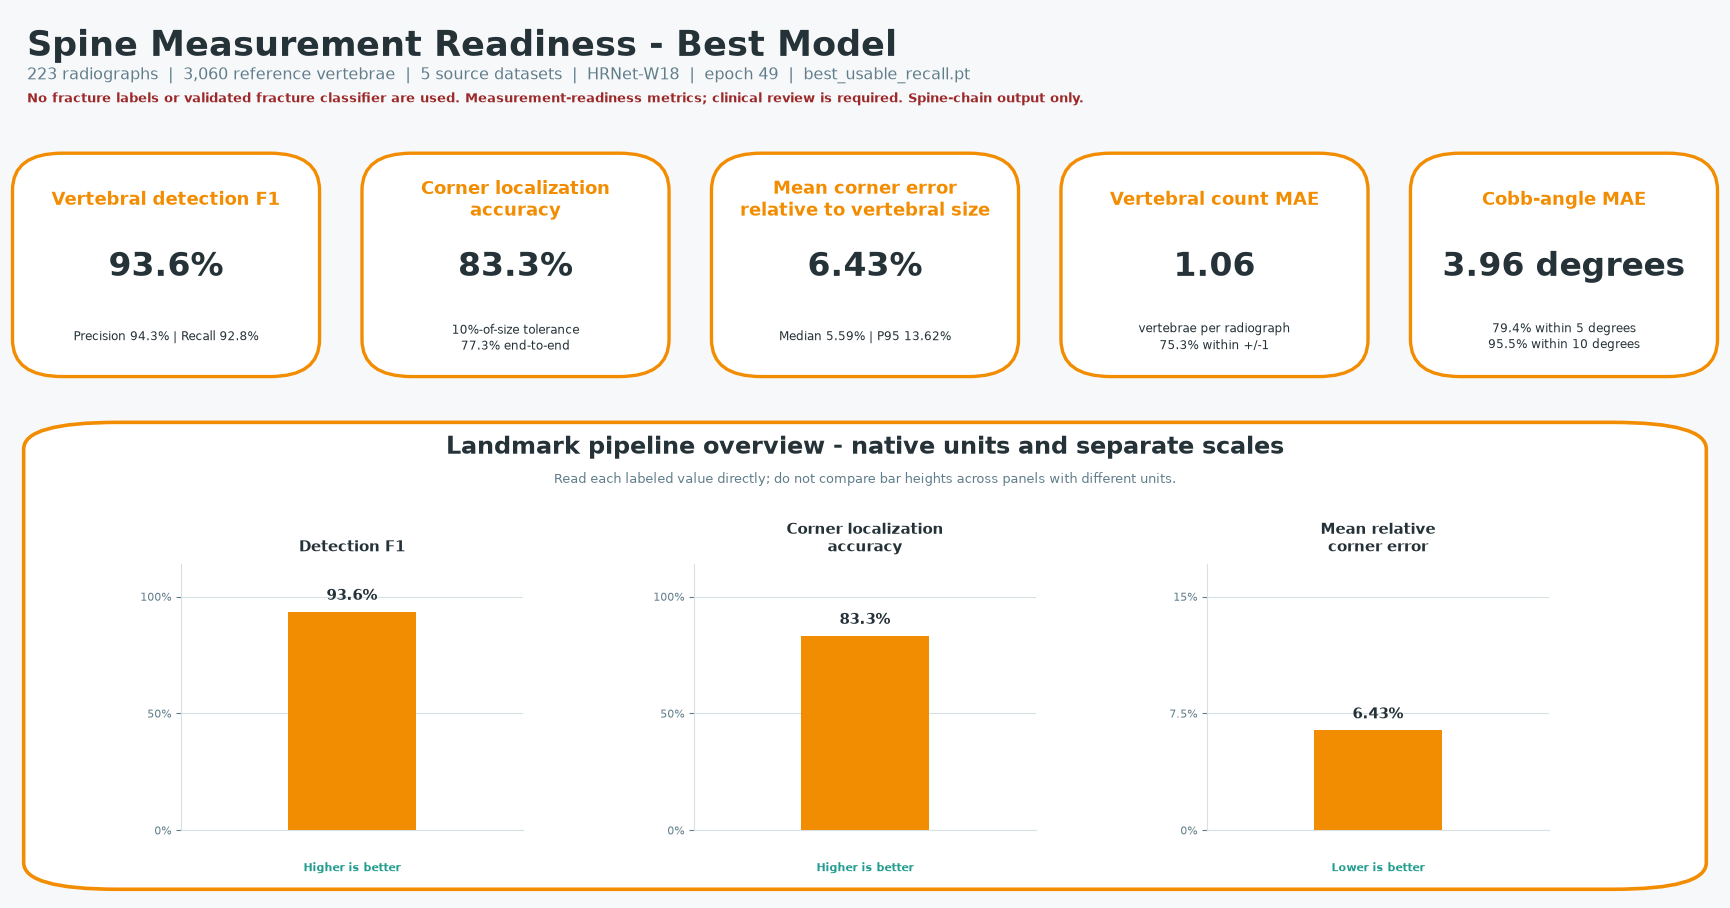

Saved editable-dashboard export to /Users/gcpuppy/Documents/AI/Spinal AI/Spine-Opportunistic-Screening/outputs/visualization/vertebral-performance-bar-dashboard.png


In [2]:
PAGE = '#f7f8fa'
WHITE = '#ffffff'
ORANGE = '#f28c00'
TEAL = '#239d8f'
DARK = '#253238'
MUTED = '#607d8b'
GRID = '#d8e0e5'
RED = '#9c2a2a'


def rounded_panel(axis, edgecolor=ORANGE, linewidth=2.4, radius=0.16):
    axis.set_axis_off()
    panel = FancyBboxPatch(
        (0.02, 0.03), 0.96, 0.94,
        boxstyle=f'round,pad=0.012,rounding_size={radius}',
        transform=axis.transAxes,
        facecolor=WHITE, edgecolor=edgecolor, linewidth=linewidth,
    )
    axis.add_patch(panel)


def metric_card(axis, title, display_value, note):
    rounded_panel(axis)
    axis.text(0.5, 0.78, title, ha='center', va='center', fontsize=13,
              fontweight='bold', color=ORANGE, transform=axis.transAxes)
    axis.text(0.5, 0.49, display_value, ha='center', va='center', fontsize=24,
              fontweight='bold', color=DARK, transform=axis.transAxes)
    axis.text(0.5, 0.19, note, ha='center', va='center', fontsize=8.8,
              color=DARK, transform=axis.transAxes, linespacing=1.3)


cards = [
    ('Vertebral detection F1', f'{values["detection_f1"]:.1f}%',
     f'Precision {values["detection_precision"]:.1f}% | Recall {values["detection_recall"]:.1f}%'),
    ('Corner localization\naccuracy', f'{values["corner_accuracy"]:.1f}%',
     f'10%-of-size tolerance\n{values["corner_end_to_end"]:.1f}% end-to-end'),
    ('Mean corner error\nrelative to vertebral size', f'{values["corner_error_mean"]:.2f}%',
     f'Median {values["corner_error_median"]:.2f}% | P95 {values["corner_error_p95"]:.2f}%'),
    ('Vertebral count MAE', f'{values["count_mae"]:.2f}',
     f'vertebrae per radiograph\n{values["count_within_one"]:.1f}% within +/-1'),
    ('Cobb-angle MAE', f'{values["cobb_mae"]:.2f} degrees',
     f'{values["cobb_within_five"]:.1f}% within 5 degrees\n{values["cobb_within_ten"]:.1f}% within 10 degrees'),
]

bar_specs = [
    {'label': 'Detection F1', 'value': values['detection_f1'], 'display': f'{values["detection_f1"]:.1f}%',
     'maximum': 100, 'ticks': [0, 50, 100], 'tick_labels': ['0%', '50%', '100%'], 'direction': 'Higher is better'},
    {'label': 'Corner localization\naccuracy', 'value': values['corner_accuracy'], 'display': f'{values["corner_accuracy"]:.1f}%',
     'maximum': 100, 'ticks': [0, 50, 100], 'tick_labels': ['0%', '50%', '100%'], 'direction': 'Higher is better'},
    {'label': 'Mean relative\ncorner error', 'value': values['corner_error_mean'], 'display': f'{values["corner_error_mean"]:.2f}%',
     'maximum': 15, 'ticks': [0, 7.5, 15], 'tick_labels': ['0%', '7.5%', '15%'], 'direction': 'Lower is better'},
]

fig = plt.figure(figsize=(18, 9.5), facecolor=PAGE)
layout = fig.add_gridspec(3, 1, left=0.025, right=0.975, top=0.97, bottom=0.035,
                          height_ratios=[0.56, 1.22, 2.55], hspace=0.12)

header = fig.add_subplot(layout[0])
header.set_axis_off()
header.text(0.01, 0.82, 'Spine Measurement Readiness - Best Model', fontsize=25,
            fontweight='bold', color=DARK, va='top')
header.text(
    0.01, 0.46,
    f'{int(overall["images"]):,} radiographs  |  {int(overall["gt_vertebrae"]):,} reference vertebrae  |  '
    f'{source_count} source datasets  |  {backbone_label}  |  epoch {epoch}  |  {checkpoint}',
    fontsize=11.5, color=MUTED, va='top',
)
header.text(
    0.01, 0.10,
    'No fracture labels or validated fracture classifier are used. Measurement-readiness metrics; clinical review is required. Spine-chain output only.',
    fontsize=9.5, fontweight='bold', color=RED, va='bottom',
)

card_grid = layout[1].subgridspec(1, 5, wspace=0.12)
for index, card in enumerate(cards):
    metric_card(fig.add_subplot(card_grid[index]), *card)

chart_frame = fig.add_subplot(layout[2])
rounded_panel(chart_frame, linewidth=2.6, radius=0.055)
chart_frame.text(0.5, 0.93, 'Landmark pipeline overview - native units and separate scales',
                 ha='center', va='center', fontsize=17, fontweight='bold', color=DARK)
chart_frame.text(0.5, 0.865, 'Read each labeled value directly; do not compare bar heights across panels with different units.',
                 ha='center', va='center', fontsize=9.5, color=MUTED)

for index, spec in enumerate(bar_specs):
    left = 0.10 + index * 0.30
    axis = chart_frame.inset_axes([left, 0.14, 0.20, 0.55])
    bar = axis.bar([0], [spec['value']], width=0.52, color=ORANGE, zorder=3)[0]
    axis.set_ylim(0, spec['maximum'] * 1.14)
    axis.set_xlim(-0.7, 0.7)
    axis.set_xticks([])
    axis.set_yticks(spec['ticks'], spec['tick_labels'])
    axis.tick_params(axis='y', labelsize=8, colors=MUTED)
    axis.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
    axis.spines[['top', 'right']].set_visible(False)
    axis.spines[['left', 'bottom']].set_color(GRID)
    axis.set_title(spec['label'], fontsize=10.5, fontweight='bold', color=DARK, pad=9)
    axis.text(bar.get_x() + bar.get_width() / 2, spec['value'] + spec['maximum'] * 0.035,
              spec['display'], ha='center', va='bottom', fontsize=10.5, fontweight='bold', color=DARK)
    axis.text(0.5, -0.12, spec['direction'], transform=axis.transAxes,
              ha='center', va='top', fontsize=8.2, color=TEAL, fontweight='bold')

OUTPUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PNG, dpi=160, facecolor=PAGE)
plt.show()
print(f'Saved editable-dashboard export to {OUTPUT_PNG}')

## Metric definitions

- **Vertebral detection F1:** harmonic mean of detection precision and recall. Matching uses predicted and reference centers within 20% of the reference vertebral diagonal; the center is only the matching rule, not the project endpoint.
- **Corner localization accuracy:** percentage of TL/TR/BL/BR corners within 10% of the reference vertebral diagonal among matched vertebrae. The end-to-end value counts corners from missed vertebrae as failures.
- **Mean corner error relative to vertebral size:** Euclidean corner error in pixels divided by that reference vertebra's diagonal, averaged across all four corners and matched vertebrae. Lower is better.
- **Vertebral count MAE:** mean absolute difference between predicted and reference vertebral counts per radiograph. Lower is better.
- **Cobb-angle MAE:** mean absolute difference between predicted and reference Cobb angles across radiographs with valid reference measurements. Lower is better.